# 🧠 Neural Network RUL Prediction Tutorial

## Learning Objectives

By the end of this tutorial, you will:
- Understand how to use Neural Networks for RUL (Remaining Useful Life) prediction
- Learn to prepare turbofan engine data for neural network training
- Build and train neural networks with different architectures (1-layer, 2-layer, 3-layer)
- Compare neural network performance with different architectures
- Evaluate RUL predictions using regression metrics
- Visualize predictions and model performance

---

## What is RUL Prediction?

**RUL (Remaining Useful Life)** is the number of operational cycles an engine has left before failure.

### Why Use Neural Networks for RUL Prediction?

- **Non-linear Relationships**: Engine degradation involves complex non-linear patterns
- **Multiple Sensors**: Neural networks can learn from many sensor inputs simultaneously
- **Feature Learning**: Can automatically discover important patterns in sensor data
- **Flexibility**: Can model complex relationships between sensor readings and RUL

### Our Goal:

Predict **how many cycles** an engine has left before failure, based on:
- Sensor readings (temperature, pressure, speed, etc.)
- Operational settings (altitude, mach number, throttle)
- Time information

This is a **regression problem** - we're predicting a continuous number.

---

## Step 1: Import Required Libraries

In [7]:
# Import libraries for data handling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Circle
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Import machine learning components
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# TensorFlow/Keras for neural networks
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Set visualization style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('ggplot')

sns.set_palette("husl")
%matplotlib inline

print("✅ Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

✅ Libraries imported successfully!
TensorFlow version: 2.20.0


## Step 1.5: Visualize Neural Network Architecture

Let's visualize how neural networks are structured for RUL prediction!

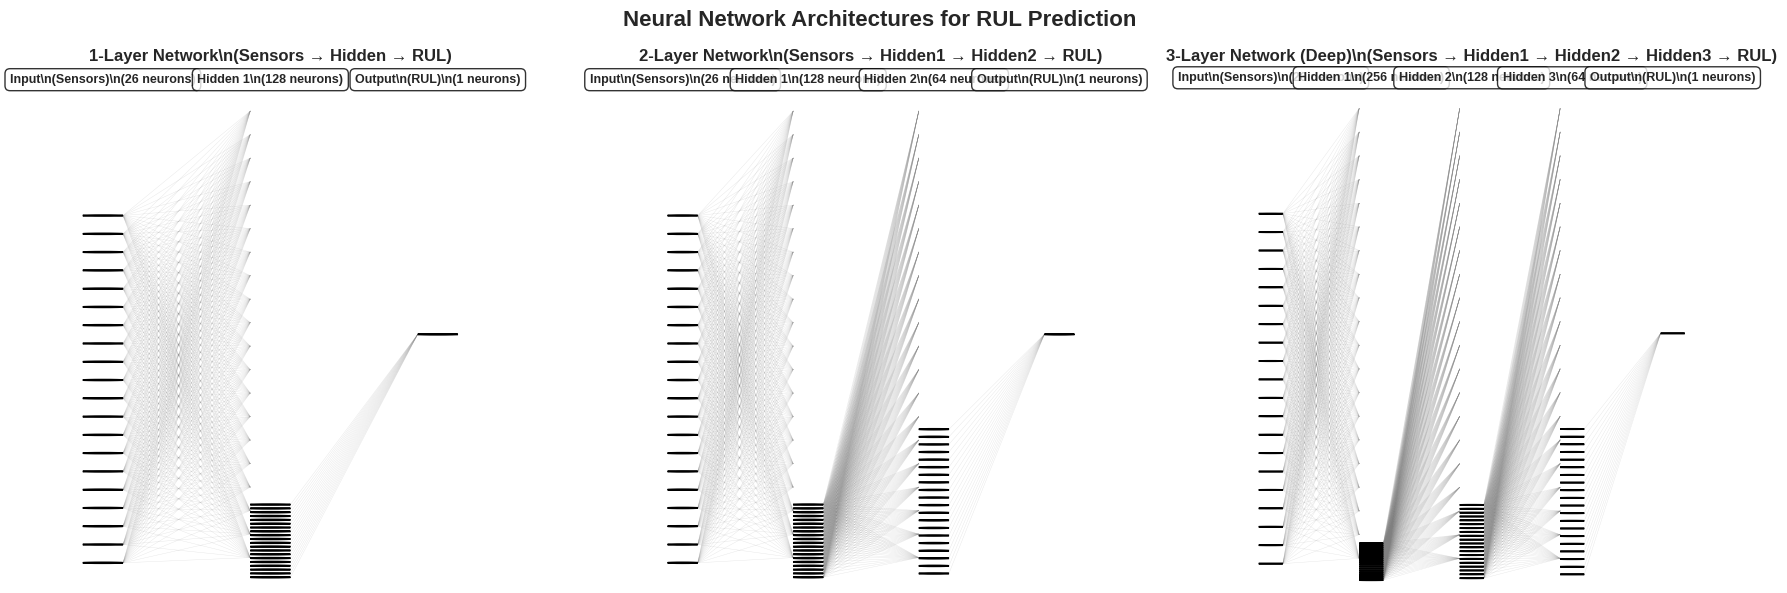

✅ Neural network architecture visualizations created!
\n💡 For RUL Prediction:
   - Input: 26 features (sensors + operational settings + time)
   - Hidden layers: Process sensor data to learn degradation patterns
   - Output: 1 value (predicted RUL in cycles)
   - More layers can capture more complex degradation patterns


In [8]:
def draw_neural_network(ax, layer_sizes, title="Neural Network Architecture"):
    """
    Draw a neural network architecture diagram
    
    Parameters:
    -----------
    ax : matplotlib axis
        Axis to draw on
    layer_sizes : list
        List of integers representing neurons in each layer
    title : str
        Title for the diagram
    """
    ax.set_xlim(0, len(layer_sizes))
    ax.set_ylim(0, max(layer_sizes) + 2)
    ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=15)
    
    # Colors for different layer types
    colors = {
        'input': '#4A90E2',      # Blue
        'hidden': '#50C878',      # Green
        'output': '#FF6B6B'       # Red
    }
    
    # Draw layers
    for layer_idx, num_neurons in enumerate(layer_sizes):
        x_pos = layer_idx + 0.5
        layer_type = 'input' if layer_idx == 0 else ('output' if layer_idx == len(layer_sizes) - 1 else 'hidden')
        color = colors[layer_type]
        
        # Draw neurons in this layer
        y_spacing = max(layer_sizes) / (num_neurons + 1)
        for neuron_idx in range(min(num_neurons, 20)):  # Limit to 20 for visualization
            y_pos = (neuron_idx + 1) * y_spacing + 0.5
            
            # Draw neuron circle
            circle = Circle((x_pos, y_pos), 0.12, color=color, ec='black', lw=1.2, zorder=3)
            ax.add_patch(circle)
            
            # Draw connections to next layer
            if layer_idx < len(layer_sizes) - 1:
                next_num_neurons = layer_sizes[layer_idx + 1]
                next_y_spacing = max(layer_sizes) / (min(next_num_neurons, 20) + 1)
                for next_neuron_idx in range(min(next_num_neurons, 20)):
                    next_y_pos = (next_neuron_idx + 1) * next_y_spacing + 0.5
                    # Draw connection line
                    ax.plot([x_pos + 0.12, x_pos + 0.88], [y_pos, next_y_pos], 
                           'gray', alpha=0.2, linewidth=0.3, zorder=1)
        
        # Add layer label
        layer_name = 'Input\\n(Sensors)' if layer_idx == 0 else ('Output\\n(RUL)' if layer_idx == len(layer_sizes) - 1 else f'Hidden {layer_idx}')
        display_neurons = num_neurons if num_neurons <= 20 else f'{num_neurons}'
        ax.text(x_pos, max(layer_sizes) + 1.0, f'{layer_name}\\n({display_neurons} neurons)', 
               ha='center', va='bottom', fontsize=9, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='black', alpha=0.8))

# Create visualization for different architectures used in RUL prediction
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Neural Network Architectures for RUL Prediction', fontsize=16, fontweight='bold')

# 1-Layer Network (26 inputs -> 128 hidden -> 1 output)
draw_neural_network(axes[0], [26, 128, 1], '1-Layer Network\\n(Sensors → Hidden → RUL)')

# 2-Layer Network (26 inputs -> 128 hidden -> 64 hidden -> 1 output)
draw_neural_network(axes[1], [26, 128, 64, 1], '2-Layer Network\\n(Sensors → Hidden1 → Hidden2 → RUL)')

# 3-Layer Network (26 inputs -> 256 hidden -> 128 hidden -> 64 hidden -> 1 output)
draw_neural_network(axes[2], [26, 256, 128, 64, 1], '3-Layer Network (Deep)\\n(Sensors → Hidden1 → Hidden2 → Hidden3 → RUL)')

plt.tight_layout()
plt.show()

print("✅ Neural network architecture visualizations created!")
print("\\n💡 For RUL Prediction:")
print("   - Input: 26 features (sensors + operational settings + time)")
print("   - Hidden layers: Process sensor data to learn degradation patterns")
print("   - Output: 1 value (predicted RUL in cycles)")
print("   - More layers can capture more complex degradation patterns")

## Step 2: Load and Prepare the Data

In [9]:
# Define data path
data_path = Path('dataset/6.+Turbofan+Engine+Degradation+Simulation+Data+Set/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData')

# Column names with actual field names
# Operational settings: Altitude, Mach, TRA (Throttle Resolver Angle)
op_settings = ['Altitude', 'Mach', 'TRA']

# Sensor names based on CMAPSS dataset documentation
sensors = [
    'T2',      # Total temperature at fan inlet
    'T24',     # Total temperature at LPC outlet
    'T30',     # Total temperature at HPC outlet
    'T50',     # Total temperature at LPT outlet
    'P2',      # Pressure at fan inlet
    'P15',     # Total pressure in bypass-duct
    'P30',     # Total pressure at HPC outlet
    'Nf',      # Physical fan speed
    'Nc',      # Physical core speed
    'epr',     # Engine pressure ratio (P50/P2)
    'Ps30',    # Static pressure at HPC outlet
    'phi',     # Ratio of fuel flow to Ps30
    'NRf',     # Corrected fan speed
    'NRc',     # Corrected core speed
    'BPR',     # Bypass Ratio
    'farB',    # Burner fuel-air ratio
    'htBleed', # Bleed Enthalpy
    'Nf_dmd',  # Demanded fan speed
    'PCNfR_dmd', # Demanded corrected fan speed
    'W31',     # HPT coolant bleed
    'W32'      # LPT coolant bleed
]

column_names = ['unit', 'time'] + op_settings + sensors

def load_data(dataset='FD001'):
    """Load training and test data from CSV files"""
    train_file = data_path / f'train_{dataset}.csv'
    test_file = data_path / f'test_{dataset}.csv'
    rul_file = data_path / f'RUL_{dataset}.csv'
    
    # Read CSV files (they already have headers)
    train_df = pd.read_csv(train_file)
    test_df = pd.read_csv(test_file)
    rul_df = pd.read_csv(rul_file)
    
    return train_df, test_df, rul_df

def calculate_rul_train(df):
    """Calculate RUL (Remaining Useful Life) for training data
    
    RUL = Maximum time for that engine - Current time
    
    Example: If an engine runs for 200 cycles total, and we're at cycle 50,
    then RUL = 200 - 50 = 150 cycles remaining.
    """
    df = df.copy()
    # For each engine, calculate: max_time - current_time
    df['RUL'] = df.groupby('unit')['time'].transform(lambda x: x.max() - x)
    return df

# Load data for FD001 dataset
train_df, test_df, rul_df = load_data('FD001')

# Calculate RUL for training data
train_df = calculate_rul_train(train_df)

print("✅ Data loaded successfully!")
print(f"\n📊 Training data shape: {train_df.shape}")
print(f"📊 Test data shape: {test_df.shape}")
print(f"🚁 Number of engines in training: {train_df['unit'].nunique()}")
print(f"🚁 Number of engines in test: {test_df['unit'].nunique()}")
print(f"⏱️  RUL range in training: {train_df['RUL'].min()} to {train_df['RUL'].max()} cycles")

✅ Data loaded successfully!

📊 Training data shape: (20631, 27)
📊 Test data shape: (13096, 26)
🚁 Number of engines in training: 100
🚁 Number of engines in test: 100
⏱️  RUL range in training: 0 to 361 cycles


## Step 3: Prepare Features and Target

We need to separate our data into:
- **Features (X)**: Input variables (sensors, settings, time)
- **Target (y)**: What we want to predict (RUL)

In [10]:
# Select features (exclude unit, time, and RUL)
feature_columns = op_settings + sensors + ['time']  # Include time as a feature
X_train = train_df[feature_columns].values
y_train = train_df['RUL'].values

print("✅ Features and target prepared!")
print(f"\n📊 Feature shape: {X_train.shape}")
print(f"   - Samples: {X_train.shape[0]:,}")
print(f"   - Features: {X_train.shape[1]}")
print(f"\n📊 Target shape: {y_train.shape}")
print(f"   - RUL range: [{y_train.min()}, {y_train.max()}] cycles")
print(f"   - Mean RUL: {y_train.mean():.2f} cycles")
print(f"   - Std RUL: {y_train.std():.2f} cycles")

✅ Features and target prepared!

📊 Feature shape: (20631, 25)
   - Samples: 20,631
   - Features: 25

📊 Target shape: (20631,)
   - RUL range: [0, 361] cycles
   - Mean RUL: 107.81 cycles
   - Std RUL: 68.88 cycles


## Step 4.5: Visualize Activation Functions

Understanding activation functions helps us understand how neural networks learn non-linear patterns in engine degradation.

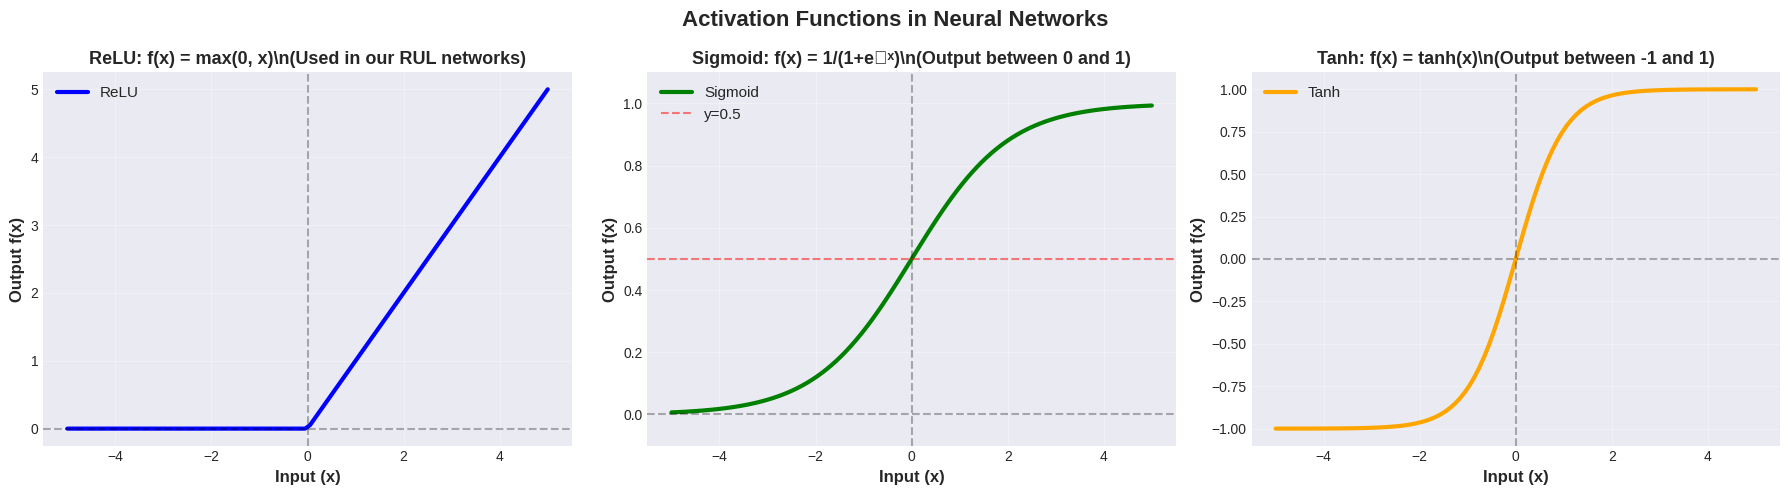

✅ Activation function visualizations created!
\n💡 Why ReLU for RUL Prediction?
   - ReLU helps networks learn non-linear degradation patterns
   - Fast computation (important for real-time predictions)
   - Prevents vanishing gradient problem during training
   - Allows networks to model complex relationships between sensors and RUL


In [11]:
# Visualize activation functions
x = np.linspace(-5, 5, 100)

# ReLU (Rectified Linear Unit) - used in our networks
relu = np.maximum(0, x)

# Sigmoid
sigmoid = 1 / (1 + np.exp(-x))

# Tanh
tanh = np.tanh(x)

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Activation Functions in Neural Networks', fontsize=16, fontweight='bold')

# ReLU
axes[0].plot(x, relu, linewidth=3, color='blue', label='ReLU')
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[0].axvline(x=0, color='black', linestyle='--', alpha=0.3)
axes[0].set_xlabel('Input (x)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Output f(x)', fontsize=12, fontweight='bold')
axes[0].set_title('ReLU: f(x) = max(0, x)\\n(Used in our RUL networks)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11)

# Sigmoid
axes[1].plot(x, sigmoid, linewidth=3, color='green', label='Sigmoid')
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[1].axvline(x=0, color='black', linestyle='--', alpha=0.3)
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='y=0.5')
axes[1].set_xlabel('Input (x)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Output f(x)', fontsize=12, fontweight='bold')
axes[1].set_title('Sigmoid: f(x) = 1/(1+e⁻ˣ)\\n(Output between 0 and 1)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=11)
axes[1].set_ylim([-0.1, 1.1])

# Tanh
axes[2].plot(x, tanh, linewidth=3, color='orange', label='Tanh')
axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[2].axvline(x=0, color='black', linestyle='--', alpha=0.3)
axes[2].set_xlabel('Input (x)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Output f(x)', fontsize=12, fontweight='bold')
axes[2].set_title('Tanh: f(x) = tanh(x)\\n(Output between -1 and 1)', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=11)
axes[2].set_ylim([-1.1, 1.1])

plt.tight_layout()
plt.show()

print("✅ Activation function visualizations created!")
print("\\n💡 Why ReLU for RUL Prediction?")
print("   - ReLU helps networks learn non-linear degradation patterns")
print("   - Fast computation (important for real-time predictions)")
print("   - Prevents vanishing gradient problem during training")
print("   - Allows networks to model complex relationships between sensors and RUL")

## Step 4: Scale the Features

Neural networks work much better with scaled data. We'll use StandardScaler to normalize features.

## Step 5.5: Visualize Model Complexity

Let's compare the complexity of different network architectures for RUL prediction.

In [12]:
# Note: Parameter counting will be done after all models are built
# See the cell after Step 7 (after all models are created) for actual parameter counts
print("💡 Parameter counting visualization will be shown after all models are built.")
print("   This ensures all models (1-layer, 2-layer, 3-layer) are available for comparison.")

💡 Parameter counting visualization will be shown after all models are built.
   This ensures all models (1-layer, 2-layer, 3-layer) are available for comparison.


In [13]:
# Scale the features (crucial for neural networks!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

print("✅ Features scaled!")
print(f"\n📊 Scaled feature statistics:")
print(f"   - Mean: {X_train_scaled.mean(axis=0)[:5]}... (should be ~0)")
print(f"   - Std: {X_train_scaled.std(axis=0)[:5]}... (should be ~1)")

# Split into training and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42
)

print(f"\n✅ Data split into training and validation sets!")
print(f"   - Training samples: {X_train_split.shape[0]:,}")
print(f"   - Validation samples: {X_val_split.shape[0]:,}")

✅ Features scaled!

📊 Scaled feature statistics:
   - Mean: [ 1.37762151e-18 -2.72080249e-17  0.00000000e+00  0.00000000e+00
  6.41034842e-14]... (should be ~0)
   - Std: [1. 1. 0. 0. 1.]... (should be ~1)

✅ Data split into training and validation sets!
   - Training samples: 16,504
   - Validation samples: 4,127


## Step 5: Build and Train 1-Layer Neural Network

Let's start with a simple 1-layer network to establish a baseline.

In [14]:
# Build 1-layer neural network
model_1layer = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],), name='hidden_layer_1'),
    layers.Dense(1, name='output_layer')  # Output layer for regression (RUL)
])

# Compile the model
model_1layer.compile(
    optimizer='adam',
    loss='mse',  # Mean Squared Error for regression
    metrics=['mae']  # Mean Absolute Error as additional metric
)

# Display model architecture
print("📊 1-Layer Neural Network Architecture:")
print("=" * 60)
model_1layer.summary()

📊 1-Layer Neural Network Architecture:


2026-02-13 15:31:00.847488: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Train the 1-layer model
print("🚀 Training 1-Layer Neural Network...")
print("=" * 60)

history_1layer = model_1layer.fit(
    X_train_split, y_train_split,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_split, y_val_split),
    verbose=1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

print("\n✅ Training completed!")

🚀 Training 1-Layer Neural Network...
Epoch 1/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 8029.2314 - mae: 69.5858 - val_loss: 3354.1621 - val_mae: 45.2300
Epoch 2/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2595.2292 - mae: 39.1679 - val_loss: 2005.5132 - val_mae: 33.9467
Epoch 3/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1734.2417 - mae: 30.4969 - val_loss: 1484.8790 - val_mae: 27.8956
Epoch 4/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1456.2638 - mae: 27.1056 - val_loss: 1372.1438 - val_mae: 26.7818
Epoch 5/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1394.7307 - mae: 26.5670 - val_loss: 1338.6505 - val_mae: 26.4883
Epoch 6/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1370.2079 - mae: 26.3285 - val_loss: 1320.5524 - val_mae: 26.2882
Epoch 7/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1353.2035 - mae: 26.1058 - val_loss: 1305.6338 - val_mae: 26.0876
Epoch 8/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1338.2012 - mae: 25.8

In [16]:
# Evaluate 1-layer model on validation set
y_pred_1layer = model_1layer.predict(X_val_split, verbose=0)

mse_1layer = mean_squared_error(y_val_split, y_pred_1layer)
mae_1layer = mean_absolute_error(y_val_split, y_pred_1layer)
rmse_1layer = np.sqrt(mse_1layer)
r2_1layer = r2_score(y_val_split, y_pred_1layer)

print("📊 1-Layer Network Performance (Validation Set):")
print("=" * 60)
print(f"MSE:  {mse_1layer:.2f}")
print(f"MAE:  {mae_1layer:.2f} cycles")
print(f"RMSE: {rmse_1layer:.2f} cycles")
print(f"R²:   {r2_1layer:.4f}")

📊 1-Layer Network Performance (Validation Set):
MSE:  1242.75
MAE:  25.08 cycles
RMSE: 35.25 cycles
R²:   0.7280


## Step 6: Build and Train 2-Layer Neural Network

Now let's try a 2-layer network to see if deeper architecture improves performance.

In [17]:
# Build 2-layer neural network
model_2layer = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],), name='hidden_layer_1'),
    layers.Dense(64, activation='relu', name='hidden_layer_2'),
    layers.Dense(1, name='output_layer')
])

# Compile the model
model_2layer.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Display model architecture
print("📊 2-Layer Neural Network Architecture:")
print("=" * 60)
model_2layer.summary()

📊 2-Layer Neural Network Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,649 (45.50 KB)

 Trainable params: 11,649 (45.50 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Train the 2-layer model
print("🚀 Training 2-Layer Neural Network...")
print("=" * 60)

history_2layer = model_2layer.fit(
    X_train_split, y_train_split,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_split, y_val_split),
    verbose=1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

print("\n✅ Training completed!")

🚀 Training 2-Layer Neural Network...
Epoch 1/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 3808.6775 - mae: 43.6083 - val_loss: 1535.1692 - val_mae: 29.3791
Epoch 2/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1474.3943 - mae: 27.9109 - val_loss: 1414.6180 - val_mae: 27.9636
Epoch 3/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1399.0485 - mae: 26.8553 - val_loss: 1377.7716 - val_mae: 27.5274
Epoch 4/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1366.4084 - mae: 26.4038 - val_loss: 1359.7528 - val_mae: 27.3469
Epoch 5/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1345.1421 - mae: 26.0978 - val_loss: 1347.4062 - val_mae: 27.1960
Epoch 6/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1328.2456 - mae: 25.8125 - val_loss: 1336.7272 - val_mae: 26.9981
Epoch 7/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1315.9082 - mae: 25.5728 - val_loss: 1330.2361 - val_mae: 26.8276
Epoch 8/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1307.3300 - mae: 25.4

In [19]:
# Evaluate 2-layer model on validation set
y_pred_2layer = model_2layer.predict(X_val_split, verbose=0)

mse_2layer = mean_squared_error(y_val_split, y_pred_2layer)
mae_2layer = mean_absolute_error(y_val_split, y_pred_2layer)
rmse_2layer = np.sqrt(mse_2layer)
r2_2layer = r2_score(y_val_split, y_pred_2layer)

print("📊 2-Layer Network Performance (Validation Set):")
print("=" * 60)
print(f"MSE:  {mse_2layer:.2f}")
print(f"MAE:  {mae_2layer:.2f} cycles")
print(f"RMSE: {rmse_2layer:.2f} cycles")
print(f"R²:   {r2_2layer:.4f}")

📊 2-Layer Network Performance (Validation Set):
MSE:  1303.73
MAE:  26.38 cycles
RMSE: 36.11 cycles
R²:   0.7146


## Step 7: Build and Train 3-Layer Neural Network (Deep Network)

Let's try a deeper 3-layer network to see if it can capture more complex patterns.

In [20]:
# Build 3-layer neural network (deep network)
model_3layer = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],), name='hidden_layer_1'),
    layers.Dense(128, activation='relu', name='hidden_layer_2'),
    layers.Dense(64, activation='relu', name='hidden_layer_3'),
    layers.Dense(1, name='output_layer')
])

# Compile the model
model_3layer.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Display model architecture
print("📊 3-Layer Neural Network Architecture (Deep Network):")
print("=" * 60)
model_3layer.summary()

📊 3-Layer Neural Network Architecture (Deep Network):


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 256)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,873 (187.00 KB)

 Trainable params: 47,873 (187.00 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Train the 3-layer model
print("🚀 Training 3-Layer Neural Network (Deep Network)...")
print("=" * 60)

history_3layer = model_3layer.fit(
    X_train_split, y_train_split,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_split, y_val_split),
    verbose=1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

print("\n✅ Training completed!")

🚀 Training 3-Layer Neural Network (Deep Network)...
Epoch 1/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2473.8396 - mae: 33.9456 - val_loss: 1407.4584 - val_mae: 28.1166
Epoch 2/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1350.1951 - mae: 25.9351 - val_loss: 1371.0626 - val_mae: 27.5415
Epoch 3/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1323.7017 - mae: 25.5211 - val_loss: 1361.6392 - val_mae: 27.3331
Epoch 4/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1309.0839 - mae: 25.3003 - val_loss: 1356.3529 - val_mae: 27.1808
Epoch 5/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1299.4342 - mae: 25.1556 - val_loss: 1351.0823 - val_mae: 27.0918
Epoch 6/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1291.9519 - mae: 25.0716 - val_loss: 1350.8821 - val_mae: 27.0988
Epoch 7/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1286.4406 - mae: 25.0102 - val_loss: 1351.1414 - val_mae: 27.0936
Epoch 8/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1280.9

In [22]:
# Evaluate 3-layer model on validation set
y_pred_3layer = model_3layer.predict(X_val_split, verbose=0)

mse_3layer = mean_squared_error(y_val_split, y_pred_3layer)
mae_3layer = mean_absolute_error(y_val_split, y_pred_3layer)
rmse_3layer = np.sqrt(mse_3layer)
r2_3layer = r2_score(y_val_split, y_pred_3layer)

print("📊 3-Layer Network Performance (Validation Set):")
print("=" * 60)
print(f"MSE:  {mse_3layer:.2f}")
print(f"MAE:  {mae_3layer:.2f} cycles")
print(f"RMSE: {rmse_3layer:.2f} cycles")
print(f"R²:   {r2_3layer:.4f}")

📊 3-Layer Network Performance (Validation Set):
MSE:  1345.09
MAE:  27.04 cycles
RMSE: 36.68 cycles
R²:   0.7056


## Step 8: Compare All Models

## Step 7.5: Visualize Actual Model Complexity

Now that all models are built, let's see the actual number of parameters in each model.

📊 Model Complexity (Parameter Counts):
1-Layer      :    3,457 parameters
2-Layer      :   11,649 parameters
3-Layer      :   47,873 parameters


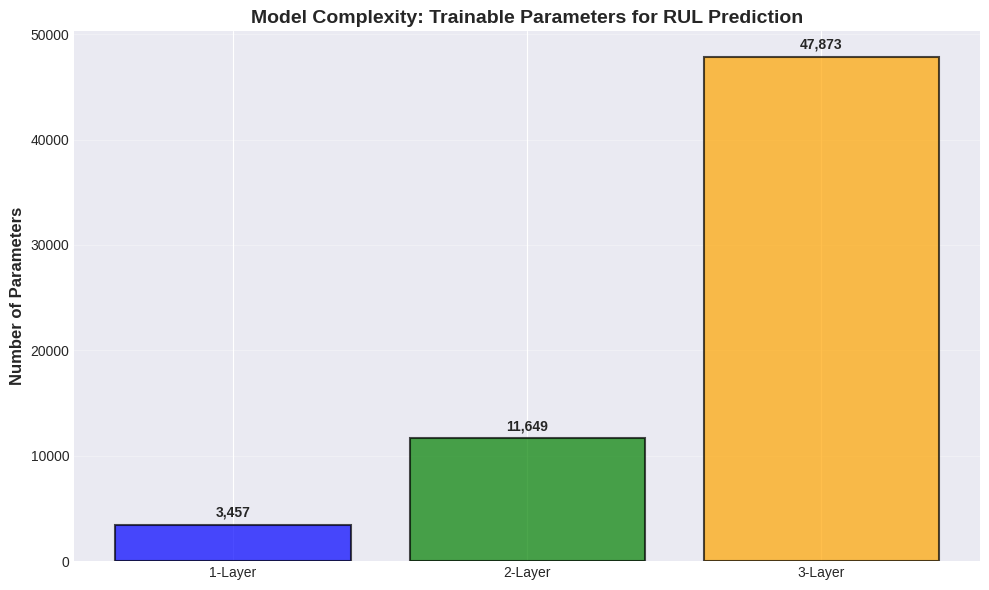


💡 Understanding Parameters:
   - Each parameter (weight/bias) is learned during training
   - More parameters = More capacity to learn complex patterns
   - But also requires more data and computation
   - For RUL prediction, we need enough parameters to capture degradation patterns


In [23]:
# After all models are built, let's visualize actual parameter counts
def count_parameters(model):
    """Count total number of trainable parameters in a model"""
    return model.count_params()

print("📊 Model Complexity (Parameter Counts):")
print("=" * 60)

models_info = [
    ('1-Layer', model_1layer),
    ('2-Layer', model_2layer),
    ('3-Layer', model_3layer)
]

param_counts = []
model_names = []

for name, model in models_info:
    params = count_parameters(model)
    param_counts.append(params)
    model_names.append(name)
    print(f"{name:12} : {params:>8,} parameters")

# Visualize actual parameter counts
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
bars = ax.bar(model_names, param_counts, color=['blue', 'green', 'orange'], 
             alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Number of Parameters', fontsize=12, fontweight='bold')
ax.set_title('Model Complexity: Trainable Parameters for RUL Prediction', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars, param_counts)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + max(param_counts)*0.01,
            f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("\n💡 Understanding Parameters:")
print("   - Each parameter (weight/bias) is learned during training")
print("   - More parameters = More capacity to learn complex patterns")
print("   - But also requires more data and computation")
print("   - For RUL prediction, we need enough parameters to capture degradation patterns")

In [24]:
# Create comparison table
comparison_data = {
    'Model': ['1-Layer', '2-Layer', '3-Layer'],
    'MSE': [mse_1layer, mse_2layer, mse_3layer],
    'MAE (cycles)': [mae_1layer, mae_2layer, mae_3layer],
    'RMSE (cycles)': [rmse_1layer, rmse_2layer, rmse_3layer],
    'R²': [r2_1layer, r2_2layer, r2_3layer]
}

comparison_df = pd.DataFrame(comparison_data)

print("📊 Model Comparison (Validation Set):")
print("=" * 80)
print(comparison_df.to_string(index=False))

# Find best model
best_model_idx = comparison_df['R²'].idxmax()
best_model = comparison_df.loc[best_model_idx, 'Model']
print(f"\n🏆 Best Model: {best_model}")
print(f"   - R²: {comparison_df.loc[best_model_idx, 'R²']:.4f}")
print(f"   - RMSE: {comparison_df.loc[best_model_idx, 'RMSE (cycles)']:.2f} cycles")
print(f"   - MAE: {comparison_df.loc[best_model_idx, 'MAE (cycles)']:.2f} cycles")

📊 Model Comparison (Validation Set):
  Model         MSE  MAE (cycles)  RMSE (cycles)       R²
1-Layer 1242.750000     25.076262      35.252659 0.727992
2-Layer 1303.732544     26.379580      36.107237 0.714644
3-Layer 1345.087769     27.036257      36.675438 0.705592

🏆 Best Model: 1-Layer
   - R²: 0.7280
   - RMSE: 35.25 cycles
   - MAE: 25.08 cycles


## Step 9: Visualize Training Progress

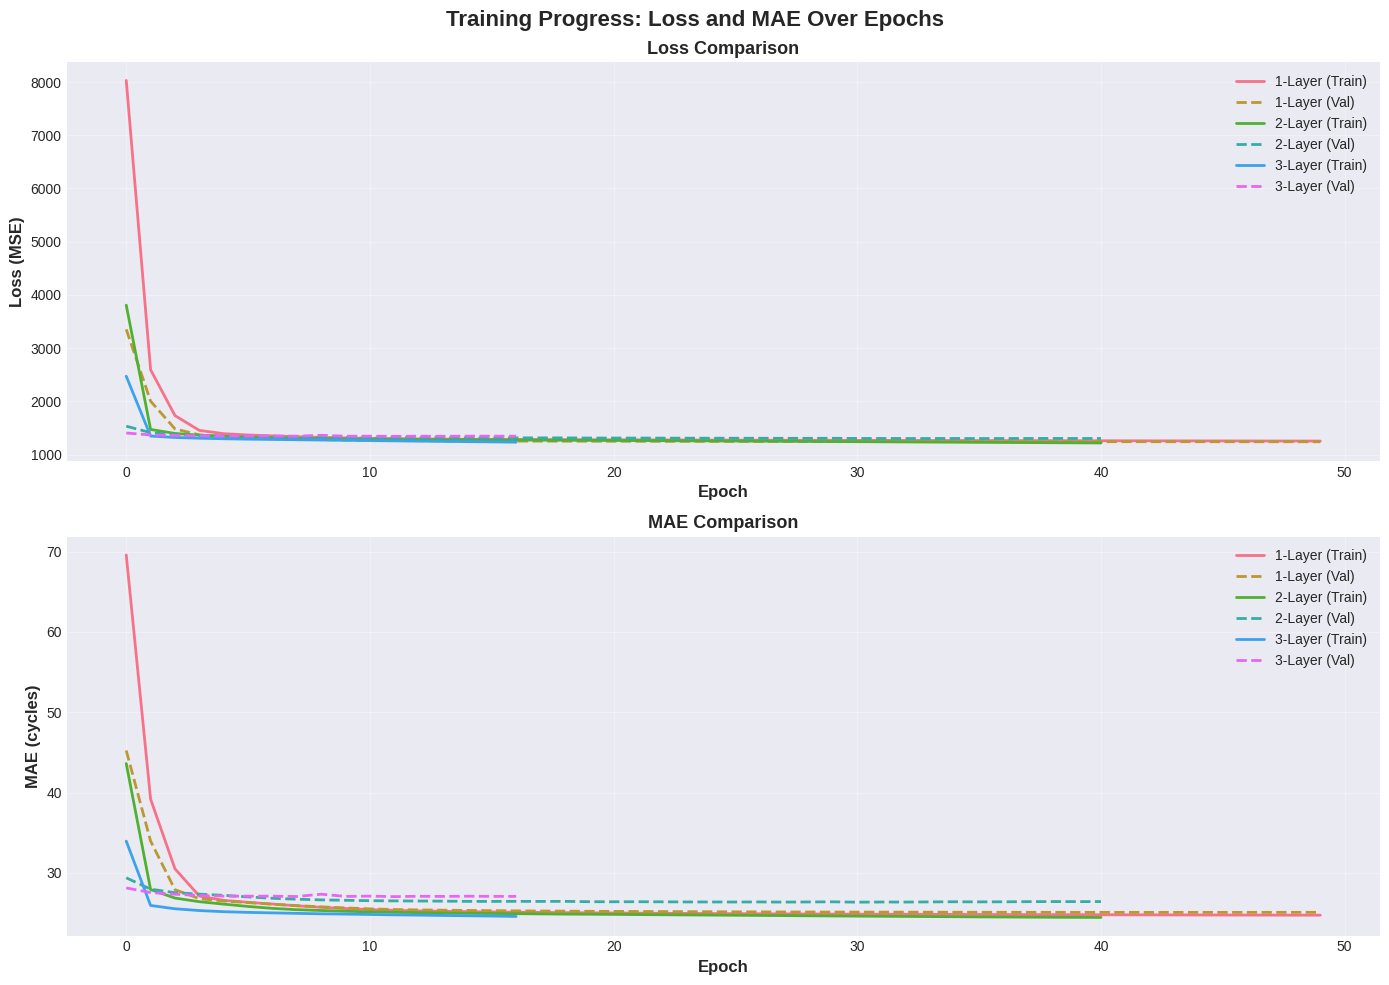

✅ Training progress visualization created!


In [25]:
# Plot training history for all models
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Training Progress: Loss and MAE Over Epochs', fontsize=16, fontweight='bold')

# Loss comparison
axes[0].plot(history_1layer.history['loss'], label='1-Layer (Train)', linestyle='-', linewidth=2)
axes[0].plot(history_1layer.history['val_loss'], label='1-Layer (Val)', linestyle='--', linewidth=2)
axes[0].plot(history_2layer.history['loss'], label='2-Layer (Train)', linestyle='-', linewidth=2)
axes[0].plot(history_2layer.history['val_loss'], label='2-Layer (Val)', linestyle='--', linewidth=2)
axes[0].plot(history_3layer.history['loss'], label='3-Layer (Train)', linestyle='-', linewidth=2)
axes[0].plot(history_3layer.history['val_loss'], label='3-Layer (Val)', linestyle='--', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss (MSE)', fontsize=12, fontweight='bold')
axes[0].set_title('Loss Comparison', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE comparison
axes[1].plot(history_1layer.history['mae'], label='1-Layer (Train)', linestyle='-', linewidth=2)
axes[1].plot(history_1layer.history['val_mae'], label='1-Layer (Val)', linestyle='--', linewidth=2)
axes[1].plot(history_2layer.history['mae'], label='2-Layer (Train)', linestyle='-', linewidth=2)
axes[1].plot(history_2layer.history['val_mae'], label='2-Layer (Val)', linestyle='--', linewidth=2)
axes[1].plot(history_3layer.history['mae'], label='3-Layer (Train)', linestyle='-', linewidth=2)
axes[1].plot(history_3layer.history['val_mae'], label='3-Layer (Val)', linestyle='--', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MAE (cycles)', fontsize=12, fontweight='bold')
axes[1].set_title('MAE Comparison', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Training progress visualization created!")

## Step 10: Visualize Predictions vs Actual RUL

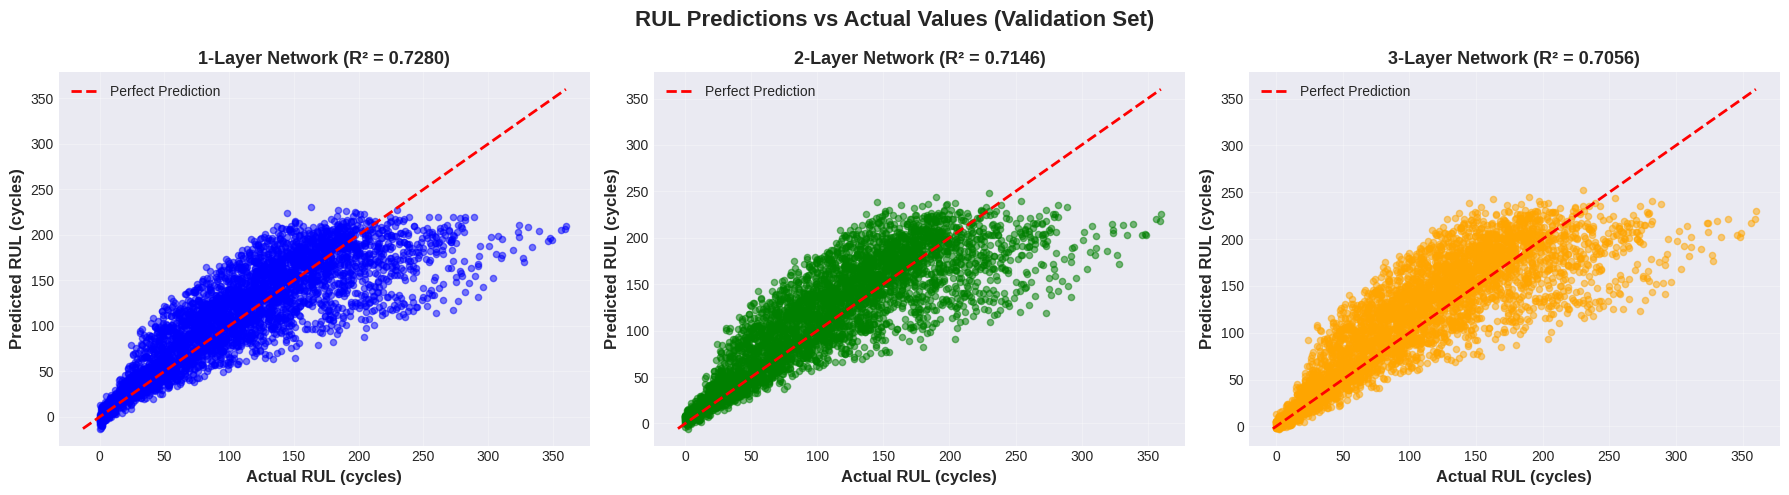

✅ Predictions visualization created!


In [26]:
# Plot predictions vs actual values
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RUL Predictions vs Actual Values (Validation Set)', fontsize=16, fontweight='bold')

# 1-Layer
axes[0].scatter(y_val_split, y_pred_1layer, alpha=0.5, s=20, color='blue')
min_val = min(y_val_split.min(), y_pred_1layer.min())
max_val = max(y_val_split.max(), y_pred_1layer.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual RUL (cycles)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted RUL (cycles)', fontsize=12, fontweight='bold')
axes[0].set_title(f'1-Layer Network (R² = {r2_1layer:.4f})', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2-Layer
axes[1].scatter(y_val_split, y_pred_2layer, alpha=0.5, s=20, color='green')
min_val = min(y_val_split.min(), y_pred_2layer.min())
max_val = max(y_val_split.max(), y_pred_2layer.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual RUL (cycles)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Predicted RUL (cycles)', fontsize=12, fontweight='bold')
axes[1].set_title(f'2-Layer Network (R² = {r2_2layer:.4f})', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3-Layer
axes[2].scatter(y_val_split, y_pred_3layer, alpha=0.5, s=20, color='orange')
min_val = min(y_val_split.min(), y_pred_3layer.min())
max_val = max(y_val_split.max(), y_pred_3layer.max())
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[2].set_xlabel('Actual RUL (cycles)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Predicted RUL (cycles)', fontsize=12, fontweight='bold')
axes[2].set_title(f'3-Layer Network (R² = {r2_3layer:.4f})', fontsize=13, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Predictions visualization created!")

## Step 11: Evaluate on Test Set

Now let's evaluate the best model on the test set to see how it performs on unseen data.

In [27]:
# Prepare test data
# For test data, we need to get the last cycle of each engine
test_last_cycle = test_df.groupby('unit').last().reset_index()
X_test = test_last_cycle[feature_columns].values
X_test_scaled = scaler.transform(X_test)

# Get actual RUL from the RUL file
y_test_actual = rul_df['RUL'].values

print("✅ Test data prepared!")
print(f"   - Test samples: {X_test_scaled.shape[0]}")
print(f"   - Actual RUL range: [{y_test_actual.min()}, {y_test_actual.max()}] cycles")

✅ Test data prepared!
   - Test samples: 100
   - Actual RUL range: [7, 145] cycles


In [28]:
# Use the best model (3-layer) for test predictions
# You can change this to use 1-layer or 2-layer if they performed better
best_model = model_3layer
y_test_pred = best_model.predict(X_test_scaled, verbose=0)

# Calculate metrics on test set
mse_test = mean_squared_error(y_test_actual, y_test_pred)
mae_test = mean_absolute_error(y_test_actual, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test_actual, y_test_pred)

print("📊 Best Model Performance on Test Set:")
print("=" * 60)
print(f"MSE:  {mse_test:.2f}")
print(f"MAE:  {mae_test:.2f} cycles")
print(f"RMSE: {rmse_test:.2f} cycles")
print(f"R²:   {r2_test:.4f}")

print(f"\n💡 Interpretation:")
print(f"   - On average, predictions are off by {mae_test:.2f} cycles")
print(f"   - The model explains {r2_test*100:.1f}% of the variance in RUL")

📊 Best Model Performance on Test Set:
MSE:  864.29
MAE:  21.35 cycles
RMSE: 29.40 cycles
R²:   0.4995

💡 Interpretation:
   - On average, predictions are off by 21.35 cycles
   - The model explains 50.0% of the variance in RUL


## Step 12: Visualize Test Set Predictions

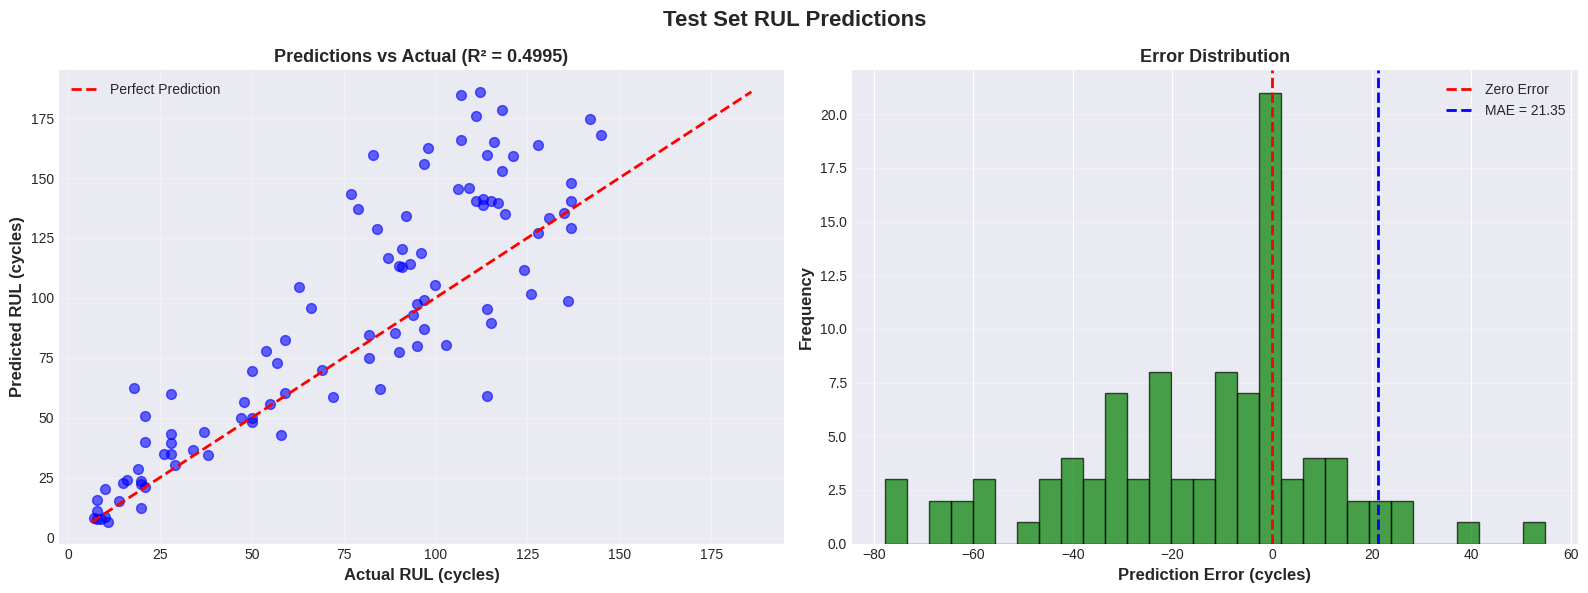

✅ Test set visualization created!


In [29]:
# Plot test set predictions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Test Set RUL Predictions', fontsize=16, fontweight='bold')

# Scatter plot: Predictions vs Actual
axes[0].scatter(y_test_actual, y_test_pred, alpha=0.6, s=50, color='blue')
min_val = min(y_test_actual.min(), y_test_pred.min())
max_val = max(y_test_actual.max(), y_test_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual RUL (cycles)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted RUL (cycles)', fontsize=12, fontweight='bold')
axes[0].set_title(f'Predictions vs Actual (R² = {r2_test:.4f})', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Error distribution
errors = y_test_actual.flatten() - y_test_pred.flatten()
axes[1].hist(errors, bins=30, alpha=0.7, color='green', edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].axvline(x=mae_test, color='blue', linestyle='--', linewidth=2, label=f'MAE = {mae_test:.2f}')
axes[1].set_xlabel('Prediction Error (cycles)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title('Error Distribution', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✅ Test set visualization created!")

## Step 13: Model Comparison Visualization

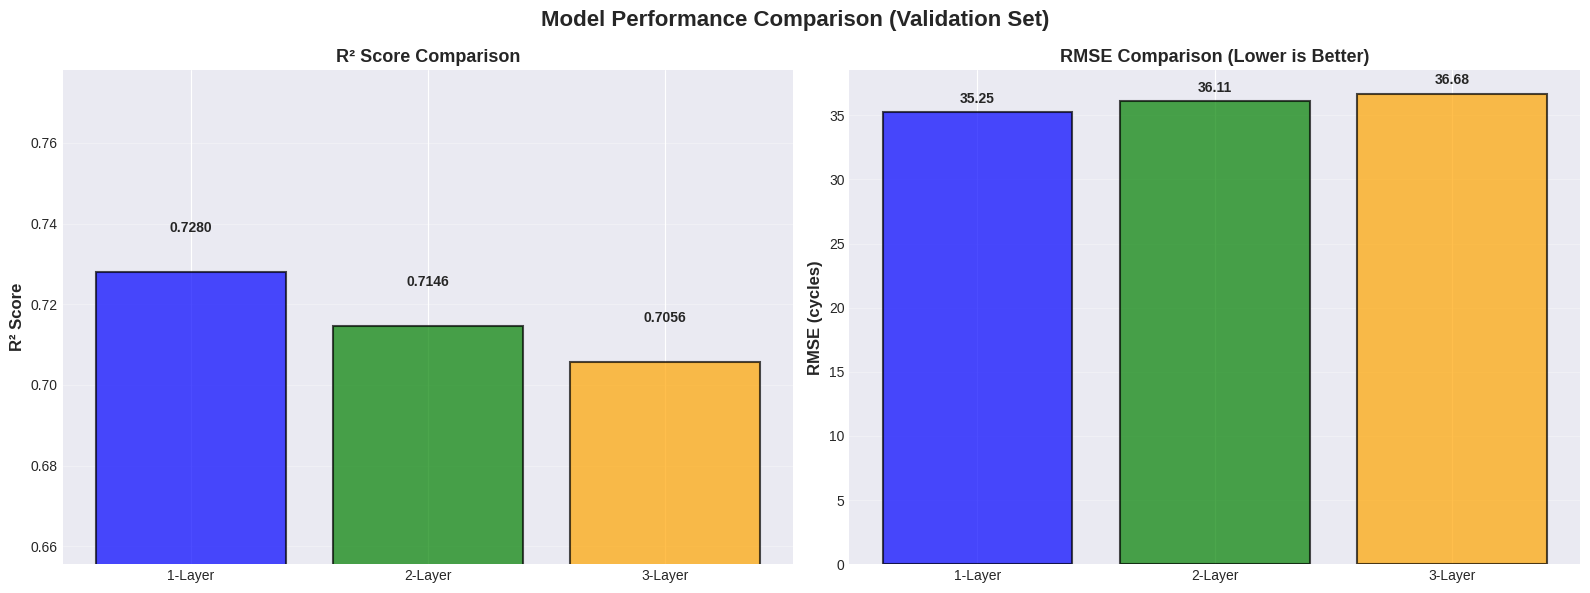

✅ Model comparison visualization created!


In [30]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Performance Comparison (Validation Set)', fontsize=16, fontweight='bold')

# R² comparison
models = ['1-Layer', '2-Layer', '3-Layer']
r2_scores = [r2_1layer, r2_2layer, r2_3layer]
colors = ['blue', 'green', 'orange']

axes[0].bar(models, r2_scores, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('R² Score Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylim([min(r2_scores) - 0.05, max(r2_scores) + 0.05])
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# RMSE comparison
rmse_scores = [rmse_1layer, rmse_2layer, rmse_3layer]

axes[1].bar(models, rmse_scores, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('RMSE (cycles)', fontsize=12, fontweight='bold')
axes[1].set_title('RMSE Comparison (Lower is Better)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(rmse_scores):
    axes[1].text(i, v + max(rmse_scores)*0.02, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Model comparison visualization created!")

## 🎓 Summary and Key Takeaways

### ✅ What You've Learned:

1. **Neural Networks for RUL Prediction**:
   - How to prepare turbofan engine data for neural network training
   - Importance of feature scaling for neural networks
   - Building networks with different depths (1, 2, 3 layers)

2. **Model Architecture Comparison**:
   - **1-Layer**: Simple baseline, fast training
   - **2-Layer**: Better for capturing non-linear patterns
   - **3-Layer**: Deep network for complex relationships

3. **Key Concepts**:
   - **Feature Scaling**: Essential for neural network performance
   - **Early Stopping**: Prevents overfitting
   - **Validation Set**: Used to monitor training and select best model
   - **Test Set**: Final evaluation on unseen data

4. **Evaluation Metrics**:
   - **R²**: How well the model explains variance in RUL
   - **RMSE**: Average prediction error in cycles
   - **MAE**: Mean absolute error in cycles

### 💡 Important Insights:

- **More layers don't always mean better performance**: Sometimes simpler models work just as well
- **Feature scaling is crucial**: Neural networks require normalized/scaled features
- **Early stopping helps**: Prevents overfitting and saves training time
- **Visualization is key**: Always plot predictions vs actual values to understand model behavior

### 📚 Best Practices for RUL Prediction:

1. **Start with simple models**: Begin with 1-2 layers
2. **Scale your features**: Use StandardScaler or MinMaxScaler
3. **Use validation set**: Monitor training and prevent overfitting
4. **Experiment with architectures**: Try different layer sizes and depths
5. **Visualize results**: Check predictions visually to understand errors
6. **Evaluate on test set**: Final evaluation should be on unseen data

### 🔧 Next Steps:

- Try different activation functions (tanh, sigmoid)
- Experiment with different optimizers (RMSprop, SGD)
- Add dropout layers to prevent overfitting
- Try different learning rates
- Feature engineering: create new features from existing ones

---

**Great job learning neural networks for RUL prediction! 🧠✈️✨**